
# 3. Model

> **Data:** `cleaned_EDA_ready_timeseries.csv`


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from pmdarima import auto_arima
from copy import deepcopy
from sklearn.impute import SimpleImputer

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

DATA_PATH = "cleaned_EDA_ready_timeseries.csv"  
TARGET = "CO2_total_mt"
CORE_FEATS = ["GDP_current_usd","Population_total","LifeExp_years","Energy_use_kg_oil_pc","Renewable_energy_pct"]
CUTOFF_YEAR = 2014 
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape, "| Years:", f"{df['Year'].min()}–{df['Year'].max()}", "| Countries:", df['Country Name'].nunique())

# basic cleaning
df = df.sort_values(["Country Name","Year"]).reset_index(drop=True)
num_cols = ["Year"] + CORE_FEATS + [TARGET]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with null target
df = df.dropna(subset=[TARGET]).copy()
df

Shape: (7830, 14) | Years: 1970–2023 | Countries: 145


,Country Name,Country Code,Year,GDP_current_usd,Population_total,LifeExp_years,Energy_use_kg_oil_pc,Renewable_energy_pct,CO2_total_mt,CO2_per_capita_ton,log1p_GDP_current_usd,log1p_Population_total,log1p_Energy_use_kg_oil_pc,log1p_CO2_total_mt
0,Albania,ALB,1970,1.578102e+09,2135479.0,65.234,813.373801,25.5,4.8450,2.268812,21.179489,14.574202,6.702419,1.765587
1,Albania,ALB,1971,1.578102e+09,2187853.0,65.896,813.373801,25.5,4.8381,2.211346,21.179489,14.598432,6.702419,1.764405
2,Albania,ALB,1972,1.578102e+09,2243126.0,66.526,813.373801,25.5,5.5183,2.460094,21.179489,14.623381,6.702419,1.874614
3,Albania,ALB,1973,1.578102e+09,2296752.0,67.107,813.373801,25.5,4.9519,2.156045,21.179489,14.647007,6.702419,1.783710
4,Albania,ALB,1974,1.578102e+09,2350124.0,67.633,813.373801,25.5,5.3296,2.267795,21.179489,14.669979,6.702419,1.845237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7825,Zimbabwe,ZWE,2019,2.571566e+10,15271368.0,61.060,412.165419,81.0,11.1692,0.731382,23.970366,16.541490,6.023848,2.498908
7826,Zimbabwe,ZWE,2020,2.686856e+10,15526888.0,61.530,373.557246,84.1,9.0721,0.584283,24.014223,16.558084,5.925745,2.309769
7827,Zimbabwe,ZWE,2021,2.724051e+10,15797210.0,60.135,405.518564,82.4,10.6233,0.672480,24.027971,16.575344,6.007630,2.453012
7828,Zimbabwe,ZWE,2022,3.278966e+10,16069056.0,62.360,416.586875,82.4,10.9630,0.682243,24.213379,16.592406,6.034493,2.481819


> ### **Set up metrics/plotting functions**

In [4]:
def eval_reg(y_true, y_pred, name="model"):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return {"model": name, "RMSE": rmse, "MAE": mae, "MAPE%": mape, "R2": r2}

def plot_actual_pred(year, y_true, y_pred, title):
    plt.figure(figsize=(9,4))
    plt.plot(year, y_true, label="Actual")
    plt.plot(year, y_pred, label="Pred")
    plt.title(title); plt.xlabel("Year"); plt.ylabel(TARGET)
    plt.legend(); plt.tight_layout(); plt.show()


# **Single-country forecasting**

In [5]:
def evaluate_country_models_once(d_country, cutoff_year, feat_cols, target_col):

    # sort by time and split train/test
    d_country = (d_country[["Year", target_col] + feat_cols].dropna(subset=[target_col]).sort_values("Year").reset_index(drop=True))

    train_df = d_country[d_country["Year"] <= cutoff_year].copy()
    test_df  = d_country[d_country["Year"]  > cutoff_year].copy()

    if len(train_df) < 5 or len(test_df) < 2:
        return None, None, None 

    ytr = train_df[target_col].values
    yte = test_df[target_col].values

    # Baseline: Naive (hold last observed)
    yhat_naive = np.repeat(ytr[-1], len(yte))
    row_naive = eval_reg(yte, yhat_naive, "NaiveLastObserved")

    # Linear regression (Year + feats)
    Xtr_lin = train_df[["Year"] + feat_cols].values
    Xte_lin = test_df[["Year"] + feat_cols].values
    lin = LinearRegression().fit(Xtr_lin, ytr)
    yhat_lin = lin.predict(Xte_lin)
    row_lin = eval_reg(yte, yhat_lin, "Linear+Features")

    # ARIMA (univariate)
    arima_uni = auto_arima(
        ytr,
        start_p=0, start_q=0,
        max_p=5, max_q=5, max_d=2,
        seasonal=False,
        stepwise=True,
        information_criterion="aic",
        suppress_warnings=True,
        error_action="ignore",
        trace=False)
    yhat_arima = arima_uni.predict(n_periods=len(yte))
    row_arima = eval_reg(yte, yhat_arima, "ARIMA(univariate)")

    # ARIMAX (with exogenous scaled features)
    scaler_exo = StandardScaler()
    Xtr_exo = scaler_exo.fit_transform(train_df[feat_cols])
    Xte_exo = scaler_exo.transform(test_df[feat_cols])
    arimax = auto_arima(ytr,X=Xtr_exo,start_p=0, start_q=0,max_p=5, max_q=5, max_d=2,
        seasonal=False,stepwise=True,information_criterion="aic",suppress_warnings=True,error_action="ignore",trace=False)
    yhat_arimax = arimax.predict(n_periods=len(yte), X=Xte_exo)
    row_arimax = eval_reg(yte, yhat_arimax, "ARIMAX(+exo)")

    # RandomForest (single-country ML)
    num_features_single = ["Year"] + feat_cols
    prep_single = ColumnTransformer([
        ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),]), num_features_single),])
    rf_single = Pipeline([
        ("prep", prep_single),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1))])
    rf_single.fit(train_df[num_features_single], ytr)
    yhat_rf = rf_single.predict(test_df[num_features_single])
    row_rf  = eval_reg(yte, yhat_rf, "RandomForestSingle")

    # XGBoost (single-country ML)
    xgb_single = Pipeline([
        ("prep", deepcopy(prep_single)),
        ("model", XGBRegressor(
            n_estimators=600,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"))])
    xgb_single.fit(train_df[num_features_single], ytr)
    yhat_xgb = xgb_single.predict(test_df[num_features_single])
    row_xgb  = eval_reg(yte, yhat_xgb, "XGBoostSingle")

    # collect metrics per model
    metrics_rows = [row_naive, row_lin, row_arima, row_arimax, row_rf, row_xgb]

    # Feature importance (RandomForest)
    rf_core = rf_single.named_steps["model"]
    feat_names_single = num_features_single
    imp_series = pd.Series(rf_core.feature_importances_, index=feat_names_single)\
                 .sort_values(ascending=False)

    feature_imp_df = (imp_series.reset_index().rename(columns={"index": "feature", 0: "importance"}))

    # for plotting convenience:
    test_period_label = f"{int(test_df['Year'].min())}–{int(test_df['Year'].max())}"
    
    return metrics_rows, feature_imp_df, test_period_label

In [6]:
focus_countries = [
    "United States","China","India",
    "Germany","Thailand","United Kingdom",
    "Saudi Arabia","Russian Federation"]

all_metrics_rows = []
all_feature_rows = []

for ctry in focus_countries:
    d_ctry = df[df["Country Name"] == ctry].copy()
    res_metrics, res_feat_imp, test_label = evaluate_country_models_once(
        d_country=d_ctry,
        cutoff_year=CUTOFF_YEAR,
        feat_cols=CORE_FEATS,
        target_col=TARGET)

    if res_metrics is None:
        print(f"Skipping {ctry}: not enough data.")
        continue

    # attach metadata
    for r in res_metrics:
        r["Country"]    = ctry
        r["TrainYears"] = f"{int(d_ctry['Year'].min())}–{CUTOFF_YEAR}"
        r["TestYears"]  = test_label
        # assign Family for later grouping
        name = r["model"]
        if "Naive" in name or "Linear" in name:
            r["Family"] = "Baseline"
        elif "ARIMA" in name:
            r["Family"] = "Statistical"
        else:
            r["Family"] = "ML"
        all_metrics_rows.append(r)

    res_feat_imp["Country"] = ctry
    all_feature_rows.append(res_feat_imp)

# results table of model performance for all chosen countries
results_country_panel = pd.DataFrame(all_metrics_rows)
print("=== Per-country model performance (test set only) ===")
display(results_country_panel)

# feature importance combined
feature_imp_all_countries = pd.concat(all_feature_rows, ignore_index=True)
print("=== Top drivers per country (RandomForestSingle) ===")
display(feature_imp_all_countries)

# summary performance by model FAMILY
family_summary = (results_country_panel.groupby("Family")[["RMSE","MAE","MAPE%","R2"]]
    .mean().sort_values("R2", ascending=False).reset_index())
print("=== Avg performance by model family ===")
display(family_summary)

=== Per-country model performance (test set only) ===


,model,RMSE,MAE,MAPE%,R2,Country,TrainYears,TestYears,Family
0,NaiveLastObserved,421.824149,366.610400,7.718582,-3.087427,United States,1970–2014,2015–2023,Baseline
1,Linear+Features,55.614591,50.228343,1.032850,0.928950,United States,1970–2014,2015–2023,Baseline
2,ARIMA(univariate),421.824149,366.610400,7.718582,-3.087427,United States,1970–2014,2015–2023,Statistical
3,ARIMAX(+exo),456.672764,400.540913,8.391983,-3.790682,United States,1970–2014,2015–2023,Statistical
4,RandomForestSingle,384.241512,309.998199,6.571717,-2.391530,United States,1970–2014,2015–2023,ML
5,XGBoostSingle,338.190184,266.151656,5.655065,-1.627297,United States,1970–2014,2015–2023,ML
6,NaiveLastObserved,1227.292166,969.341244,7.798641,-1.241419,China,1970–2014,2015–2023,Baseline
7,Linear+Features,872.922037,729.676123,5.933473,-0.133908,China,1970–2014,2015–2023,Baseline
8,ARIMA(univariate),583.627872,485.086378,3.967098,0.493127,China,1970–2014,2015–2023,Statistical
9,ARIMAX(+exo),943.659988,783.820597,6.365822,-0.325129,China,1970–2014,2015–2023,Statistical


=== Top drivers per country (RandomForestSingle) ===


,feature,importance,Country
0,GDP_current_usd,0.226920,United States
1,Year,0.208271,United States
2,Population_total,0.206557,United States
3,LifeExp_years,0.201228,United States
4,Energy_use_kg_oil_pc,0.129001,United States
5,Renewable_energy_pct,0.028023,United States
6,Renewable_energy_pct,0.293238,China
7,Energy_use_kg_oil_pc,0.216077,China
8,GDP_current_usd,0.143471,China
9,Population_total,0.127341,China


=== Avg performance by model family ===


,Family,RMSE,MAE,MAPE%,R2
0,ML,337.669081,277.459135,9.758357,-2.575049
1,Baseline,246.777148,202.879764,7.949157,-3.601137
2,Statistical,234.508695,197.765453,9.135652,-10.264009


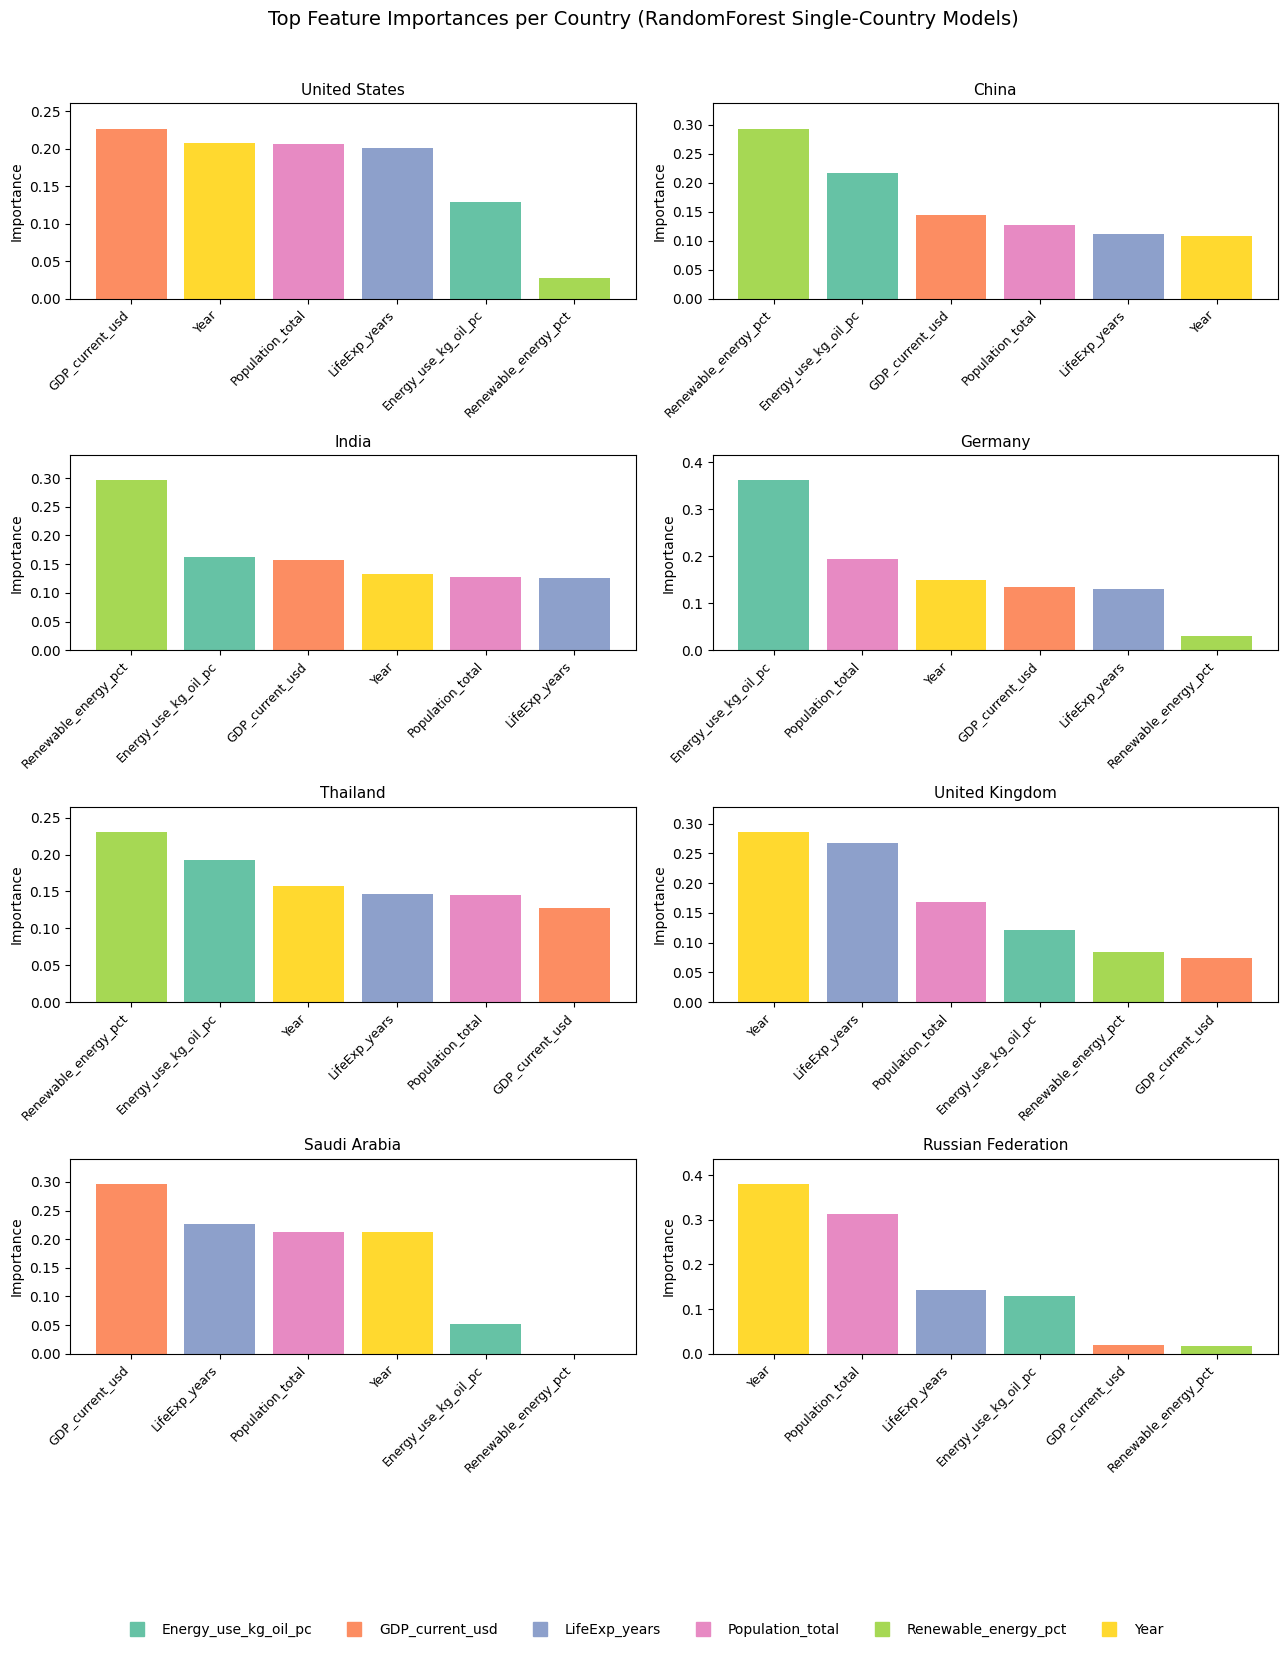

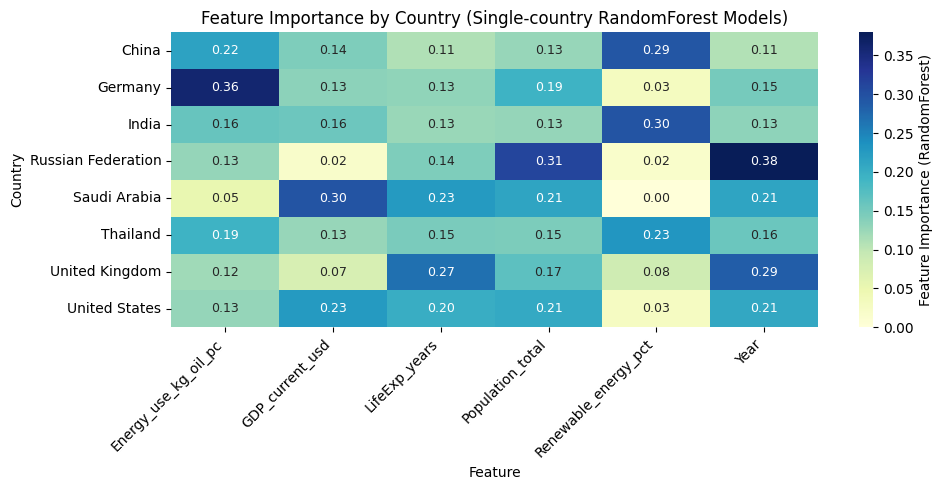

In [7]:
pivot_imp = (feature_imp_all_countries.pivot_table(index="Country",columns="feature",values="importance",aggfunc="mean").fillna(0))
countries_to_plot = [c for c in focus_countries if c in pivot_imp.index]
n_countries = len(countries_to_plot)
n_cols = 2
n_rows = math.ceil(n_countries / n_cols)

feature_names = pivot_imp.columns.tolist()
colors = sns.color_palette("Set2", len(feature_names))
color_map = dict(zip(feature_names, colors))

fig, axes = plt.subplots(n_rows,n_cols,figsize=(13, 4 * n_rows),squeeze=False)

for idx, country in enumerate(countries_to_plot):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    imp_series = pivot_imp.loc[country].sort_values(ascending=False)
    bar_colors = [color_map[f] for f in imp_series.index]
    ax.bar(range(len(imp_series)),imp_series.values,color=bar_colors)

    ymax = imp_series.values.max()
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Importance")

    ax.set_xticks(range(len(imp_series)))
    ax.set_xticklabels(imp_series.index,rotation=45,ha="right",fontsize=9)
    ax.grid(False)

for j in range(idx + 1, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")

legend_handles = [plt.Line2D([0], [0],marker="s",color=color_map[f],label=f,markersize=10,linestyle="") for f in feature_names]

fig.legend(handles=legend_handles,loc="lower center",ncol=len(feature_names),bbox_to_anchor=(0.5, -0.03),fontsize=10,frameon=False)
plt.suptitle("Top Feature Importances per Country (RandomForest Single-Country Models)",fontsize=14,y=0.995)
plt.tight_layout(rect=[0, 0.07, 1, 0.98])
plt.show()

# Heatmap summary
fig, ax_heat = plt.subplots(figsize=(10,5))
sns.heatmap(pivot_imp,annot=True,fmt=".2f",cmap="YlGnBu",
    cbar_kws={"label": "Feature Importance (RandomForest)"},
    annot_kws={"size":9},ax=ax_heat)
ax_heat.set_title("Feature Importance by Country (Single-country RandomForest Models)")
ax_heat.set_xlabel("Feature")
ax_heat.set_ylabel("Country")
plt.setp(ax_heat.get_xticklabels(), rotation=45, ha="right")
ax_heat.grid(False)
plt.tight_layout()
plt.show()


# **Cross-country forecasting**

In [14]:
num_features_global = ["Year"] + CORE_FEATS
cat_features_global = ["Country Code"]
global_feat_cols    = num_features_global + cat_features_global

preprocess_global = ColumnTransformer([("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),]), num_features_global),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_global),])

def build_rf_global():
    return Pipeline([("prep", preprocess_global),
                    ("model", RandomForestRegressor(n_estimators=500,random_state=RANDOM_STATE,n_jobs=-1))])

def build_xgb_global():
    return Pipeline([("prep", preprocess_global),
                    ("model", XGBRegressor(n_estimators=800,max_depth=6,learning_rate=0.05,subsample=0.8,
                    colsample_bytree=0.8,random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"))])


# Baseline
def global_mean_baseline(train_df, test_df, target_col):
    y_true = test_df[target_col].values
    y_pred = np.repeat(train_df[target_col].mean(), len(y_true))
    return eval_reg(y_true, y_pred, "Global-MeanBaseline")

def global_naive_lastobserved(train_df, test_df, target_col):
    preds = []
    trues = []

    # last observed value per country in the training window
    last_by_country = (train_df.sort_values("Year").groupby("Country Name")[target_col].last())

    for c_name, g_test in test_df.groupby("Country Name"):
        if c_name not in last_by_country.index:
            continue
        y_true_c = g_test[target_col].values
        y_pred_c = np.repeat(last_by_country.loc[c_name], len(y_true_c))
        trues.append(y_true_c)
        preds.append(y_pred_c)

    if len(trues) == 0:
        return None

    y_true_all = np.concatenate(trues)
    y_pred_all = np.concatenate(preds)
    return eval_reg(y_true_all, y_pred_all, "Global-NaiveLastObserved")

def evaluate_global_time_cv_all_models(df, target_col, feat_cols, year_folds, horizon=5):
    rows = []

    for cutoff in year_folds:
        # define train/test split for this fold
        train_df = (df[df["Year"] <= cutoff].dropna(subset=[target_col]).copy())
        test_df = (df[(df["Year"] > cutoff) & (df["Year"] <= cutoff + horizon)].dropna(subset=[target_col]).copy())

        if len(train_df) < 10 or len(test_df) < 2:
            print(f"[skip cutoff {cutoff}] not enough data")
            continue

        # baselines
        row_mean  = global_mean_baseline(train_df, test_df, target_col)
        row_naive = global_naive_lastobserved(train_df, test_df, target_col)

        # Random Forest (global pooled ML)
        rf_g = build_rf_global()
        rf_g.fit(train_df[feat_cols], train_df[target_col].values)
        yhat_rf = rf_g.predict(test_df[feat_cols])
        row_rf  = eval_reg(test_df[target_col].values,yhat_rf,"Global-RandomForestRegressor" )

        # XGBoost (global pooled ML)
        xgb_g = build_xgb_global()
        xgb_g.fit(train_df[feat_cols], train_df[target_col].values)
        yhat_xgb = xgb_g.predict(test_df[feat_cols])
        row_xgb  = eval_reg(test_df[target_col].values,yhat_xgb,"Global-XGBRegressor")

        test_start = int(test_df["Year"].min())
        test_end   = int(test_df["Year"].max())

        fold_meta = {
            "fold":              f"{test_start}-{test_end}",
            "train_years":       f"<= {cutoff}",
            "test_years":        f"{test_start}-{test_end}",
            "Countries_test":    test_df["Country Name"].nunique(),
            "Rows_test":         len(test_df),}

        for row in [row_mean, row_naive, row_rf, row_xgb]:
            if row is None:
                continue

            row.update(fold_meta)

            model_name = row["model"]
            if ("MeanBaseline" in model_name) or ("NaiveLastObserved" in model_name):
                row["Family"] = "Baseline"
            else:
                row["Family"] = "ML"

            rows.append(row)

    return pd.DataFrame(rows)

In [15]:
year_folds = [1975, 1985, 1995, 2005, 2015, 2020]

cv_global_all = evaluate_global_time_cv_all_models(df=df,target_col=TARGET,feat_cols=global_feat_cols,year_folds=year_folds,horizon=5)

print("=== Global panel CV (all folds, all models) ===")
display(cv_global_all)

cv_global_summary = (cv_global_all.groupby("model")[["RMSE","MAE","MAPE%","R2"]].mean().sort_values("R2", ascending=False).reset_index())

print("=== Average performance across all folds ===")
display(cv_global_summary)

=== Global panel CV (all folds, all models) ===


,model,RMSE,MAE,MAPE%,R2,fold,train_years,test_years,Countries_test,Rows_test,Family
0,Global-MeanBaseline,471.600727,166.259568,7236.508552,-0.001404,1976-1980,<= 1975,1976-1980,143,715,Baseline
1,Global-NaiveLastObserved,49.410359,13.622154,16.718091,0.989008,1976-1980,<= 1975,1976-1980,143,715,Baseline
2,Global-RandomForestRegressor,190.225644,43.885585,73.441737,0.837071,1976-1980,<= 1975,1976-1980,143,715,ML
3,Global-XGBRegressor,81.210649,28.598834,74.261597,0.970305,1976-1980,<= 1975,1976-1980,143,715,ML
4,Global-MeanBaseline,502.835846,182.252441,6116.399207,-0.001905,1986-1990,<= 1985,1986-1990,143,715,Baseline
5,Global-NaiveLastObserved,47.433952,11.793327,12.574847,0.991084,1986-1990,<= 1985,1986-1990,143,715,Baseline
6,Global-RandomForestRegressor,84.227216,27.071645,47.469306,0.971889,1986-1990,<= 1985,1986-1990,143,715,ML
7,Global-XGBRegressor,78.076563,24.100326,46.327304,0.975845,1986-1990,<= 1985,1986-1990,143,715,ML
8,Global-MeanBaseline,588.247431,201.953916,3242.796608,-0.002795,1996-2000,<= 1995,1996-2000,143,715,Baseline
9,Global-NaiveLastObserved,46.717428,12.619764,13.942787,0.993675,1996-2000,<= 1995,1996-2000,143,715,Baseline


=== Average performance across all folds ===


,model,RMSE,MAE,MAPE%,R2
0,Global-NaiveLastObserved,78.280196,16.106957,12.295557,0.987657
1,Global-XGBRegressor,142.777339,31.339163,42.181684,0.962469
2,Global-RandomForestRegressor,154.898563,35.004610,44.684645,0.946331
3,Global-MeanBaseline,773.332767,231.192814,3683.124348,-0.004074


=== Global RandomForest Feature Importance (train ≤ 2020) ===


,feature,importance
0,GDP_current_usd,0.543387
1,Population_total,0.190945
2,Energy_use_kg_oil_pc,0.074936
3,Country Code_USA,0.055555
4,Renewable_energy_pct,0.050555
5,Country Code_RUS,0.027838
6,Country Code_CHN,0.019978
7,LifeExp_years,0.018588
8,Country Code_JPN,0.008480
9,Year,0.004700


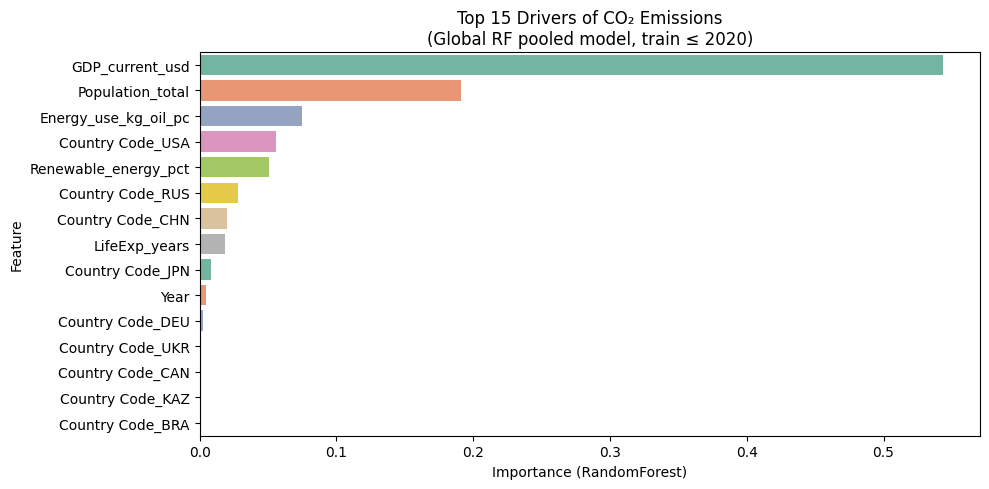

In [18]:
CUTOFF_FOR_IMPORTANCE = 2020

train_df_global = (df[df["Year"] <= CUTOFF_FOR_IMPORTANCE].dropna(subset=[TARGET]).copy())

# Fit the pooled global RandomForest on that training slice
rf_global_full = build_rf_global()
rf_global_full.fit(train_df_global[global_feat_cols],train_df_global[TARGET].values)

# Extract feature names after preprocessing
#    - numeric block keeps same order as num_features_global
#    - categorical block becomes one-hot columns like Country Code_USA, etc.
rf_core_global = rf_global_full.named_steps["model"]
prep_global    = rf_global_full.named_steps["prep"]

# numeric feature names (unchanged)
num_out_names = num_features_global

# categorical expanded names from OneHotEncoder
ohe = prep_global.named_transformers_["cat"]
cat_out_names = list(ohe.get_feature_names_out(cat_features_global))

# final feature space seen by RF
global_feat_names_after = num_out_names + cat_out_names

# Build importance series
global_importances = pd.Series(rf_core_global.feature_importances_,index=global_feat_names_after).sort_values(ascending=False)

# top k important features
top_k = 15
top_global_imp = (global_importances.head(top_k).reset_index()
                  .rename(columns={"index": "feature", 0: "importance", rf_core_global.__class__.__name__: "importance"}))

print(f"=== Global RandomForest Feature Importance (train ≤ {CUTOFF_FOR_IMPORTANCE}) ===")
display(top_global_imp)

# Plot: horizontal bar for readability
plt.figure(figsize=(10, 5))
sns.barplot(x="importance",y="feature",data=top_global_imp,palette="Set2")
plt.xlabel("Importance (RandomForest)")
plt.ylabel("Feature")
plt.title(f"Top {top_k} Drivers of CO₂ Emissions\n(Global RF pooled model, train ≤ {CUTOFF_FOR_IMPORTANCE})")
plt.grid(False)
plt.tight_layout()
plt.show()

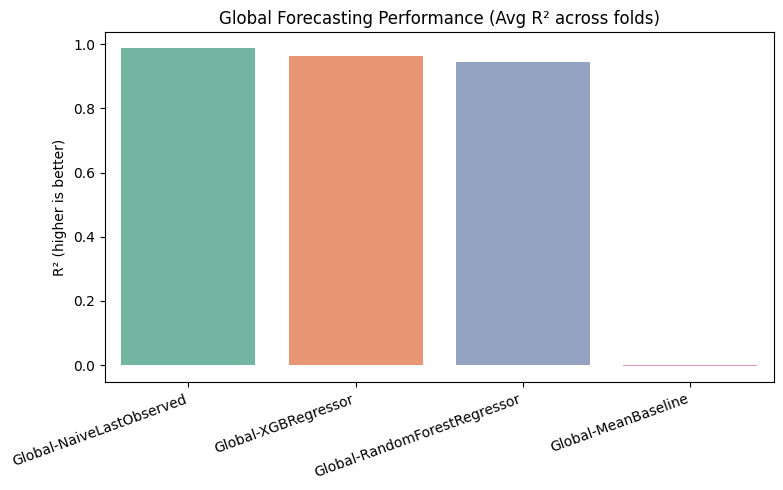

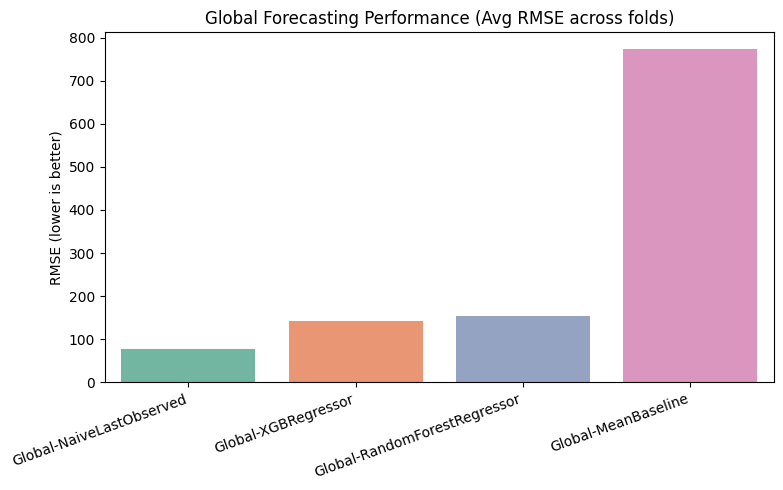

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x="model",y="R2",data=cv_global_summary,palette="Set2")
plt.title("Global Forecasting Performance (Avg R² across folds)")
plt.ylabel("R² (higher is better)")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="model",y="RMSE",data=cv_global_summary,palette="Set2")
plt.title("Global Forecasting Performance (Avg RMSE across folds)")
plt.ylabel("RMSE (lower is better)")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.grid(False)
plt.tight_layout()
plt.show()